# **Cota de Markov**
Si $X$ es una variable aleatoria no negativa tal que existe $E[X]$ y $a>0$, entonces:
$$P[X\geq a] \leq \frac{E[X]}{a}$$

**Demostración**

Se deduce siguiendo el siguiente razonamiento:
\begin{equation}
\begin{split}
E[X] & = \sum_{x}xP(x) \\
 & \geq \sum_{x\geq a}xP(x) \\
 & \geq \sum_{x\geq a}aP(x) \\
 & = a\sum_{x\geq a}P(x) \\
 & = aP(X\geq a)
 \end{split}
\end{equation}
De este modo resulta $E[X]\geq aP(X\geq a)$ y por tanto, $P(X\geq a)\leq \frac{E[X]}{a}$$\tag*{$\square$}$
Veamos ahora para algunas distribuciones que la desigualdad se cumple efectivamente.

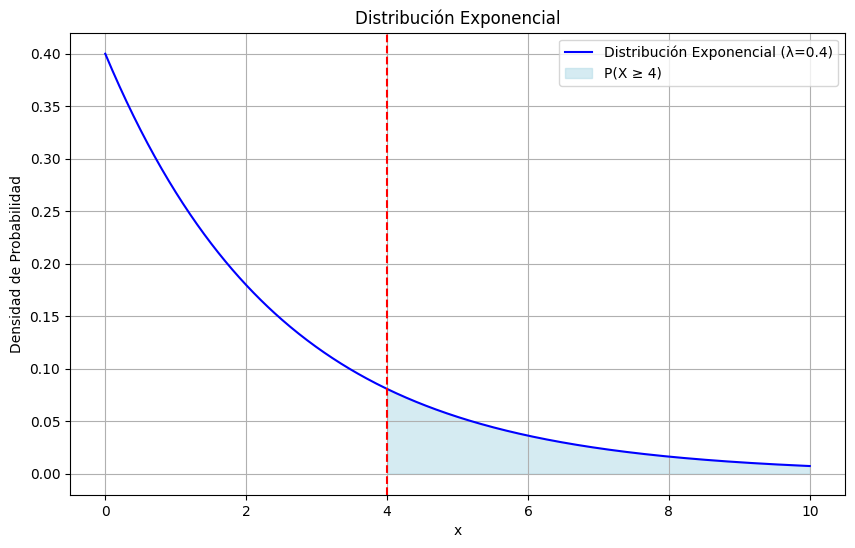

El área sombreada (P(X ≥ 4)) es: 0.2019
El valor E[X]/4 es: 0.6250
La desigualdad de Markov (P(X ≥ 4) ≤ E[X]/4) se satisface: 0.2019 ≤ 0.6250


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon


lam = 0.4                                 # Parámetro de la distribución exponencial (lambda)
x = np.linspace(0, 10, 500)
pdf = expon.pdf(x, scale=1/lam)           # Función de densidad de probabilidad
a = 4                                     # Valor para a
area_sombreada = expon.sf(a, scale=1/lam) # Calcula el área P(X >= a)
expected_value_over_a = (1/lam)/a         # Calcula el valor de E[X]/a

plt.figure(figsize=(10, 6))
plt.plot(x, pdf, label=f'Distribución Exponencial (λ={lam})', color='blue')

x_fill = np.linspace(a, 10, 100)          # Sombrea la región para X >= a
pdf_fill = expon.pdf(x_fill, scale=1/lam)
plt.fill_between(x_fill, pdf_fill, color='lightblue', alpha=0.5, label=f'P(X ≥ {a})')

plt.title('Distribución Exponencial')
plt.xlabel('x')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid(True)
plt.axvline(a, color='red', linestyle='--', label=f'a = {a}')
plt.show()

print(f"El área sombreada (P(X ≥ {a})) es: {area_sombreada:.4f}")
print(f"El valor E[X]/{a} es: {expected_value_over_a:.4f}")

if area_sombreada <= expected_value_over_a:
    print(f"La desigualdad de Markov (P(X ≥ {a}) ≤ E[X]/{a}) se satisface: {area_sombreada:.4f} ≤ {expected_value_over_a:.4f}")
else:
    print(f"La desigualdad de Markov (P(X ≥ {a}) ≤ E[X]/{a}) NO se satisface: {area_sombreada:.4f} > {expected_value_over_a:.4f}")

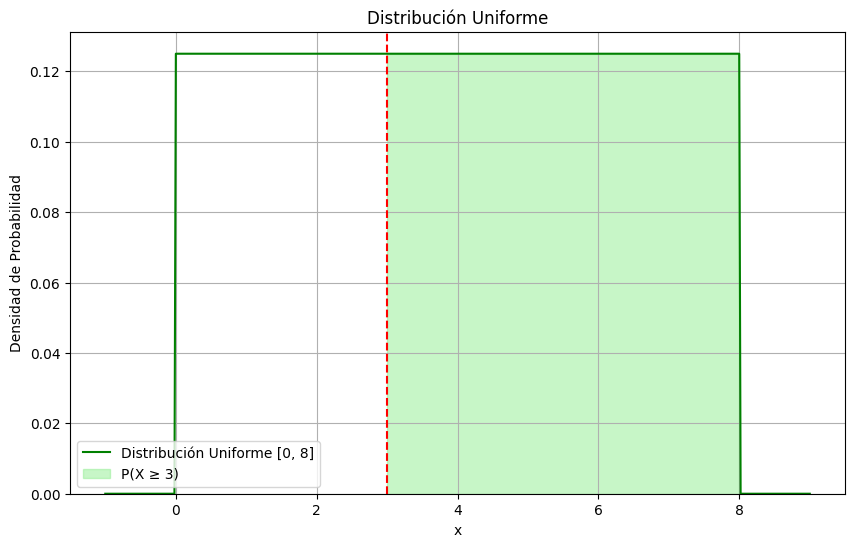

El área sombreada (P(X ≥ 3)) es: 0.6250
El valor E[X]/3 es: 1.3333
La desigualdad de Markov (P(X ≥ 3) ≤ E[X]/3) se satisface: 0.6250 ≤ 1.3333


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform

uni_min = 0                                        # Parámetros de la distribución uniforme (Límites inferior y superior)
uni_max = 8
uni_scale = uni_max - uni_min
x = np.linspace(uni_min - 1, uni_max + 1, 500)
pdf = uniform.pdf(x, loc=uni_min, scale=uni_scale) # Función de densidad de probabilidad
a = 3                                              # Valor para a
area_sombreada = uniform.sf(a, loc=uni_min, scale=uni_scale) # Calcular el área P(X >= a)
expected_value = (uni_min + uni_max) / 2
expected_value_over_a = expected_value / a         # Calcula el valor esperado E[X]/a

plt.figure(figsize=(10, 6))
plt.plot(x, pdf, label=f'Distribución Uniforme [{uni_min}, {uni_max}]', color='green')

x_fill = np.linspace(max(a, uni_min), uni_max, 100) # Sombrea la región para X >= a (Asegura que x_fill no empiece antes de uni_min)
pdf_fill = uniform.pdf(x_fill, loc=uni_min, scale=uni_scale)
plt.fill_between(x_fill, pdf_fill, color='lightgreen', alpha=0.5, label=f'P(X ≥ {a})')

plt.title('Distribución Uniforme')
plt.xlabel('x')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid(True)
plt.axvline(a, color='red', linestyle='--', label=f'a = {a}')
plt.ylim(bottom=0)
plt.show()

print(f"El área sombreada (P(X ≥ {a})) es: {area_sombreada:.4f}")
print(f"El valor E[X]/{a} es: {expected_value_over_a:.4f}")

if area_sombreada <= expected_value_over_a:
    print(f"La desigualdad de Markov (P(X ≥ {a}) ≤ E[X]/{a}) se satisface: {area_sombreada:.4f} ≤ {expected_value_over_a:.4f}")
else:
    print(f"La desigualdad de Markov (P(X ≥ {a}) ≤ E[X]/{a}) NO se satisface: {area_sombreada:.4f} > {expected_value_over_a:.4f}")

# **Cota de Chebyshev**
Si $X$ es una variable aleatoria no negativa tal que existe $Var(X)$ y $a>0$, entonces:
$$P\big[\big|X-E[X]\big|\geq a\big] \leq \frac{Var(X)}{a^2}$$

**Demostración**

Dado que $|X-E[X]|\geq a$, entonces $(X-E[X])^2\geq a^2$ (de hecho, las probabilidades de ambos escenarios es la misma), ahora definamos una nueva variable aleatoria $Y:=(X-E[X])^2$, entonces por la Cota de Markov y la definición de varianza se obtiene:
\begin{equation}
\begin{split}
P(Y\geq a^2) & \leq \frac{E[Y]}{a^2} \\
 & = \frac{E\big[(X-E[X])^2\big]}{a^2} \\
 & = \frac{Var(X)}{a^2}
 \end{split}
\end{equation}
Por tanto, $P\big[\big|X-E[X]\big|\geq a\big] \leq \frac{Var(X)}{a^2}\tag*{$\square$}$
Veamos ahora para algunas distribuciones que la desigualdad se cumple efectivamente.

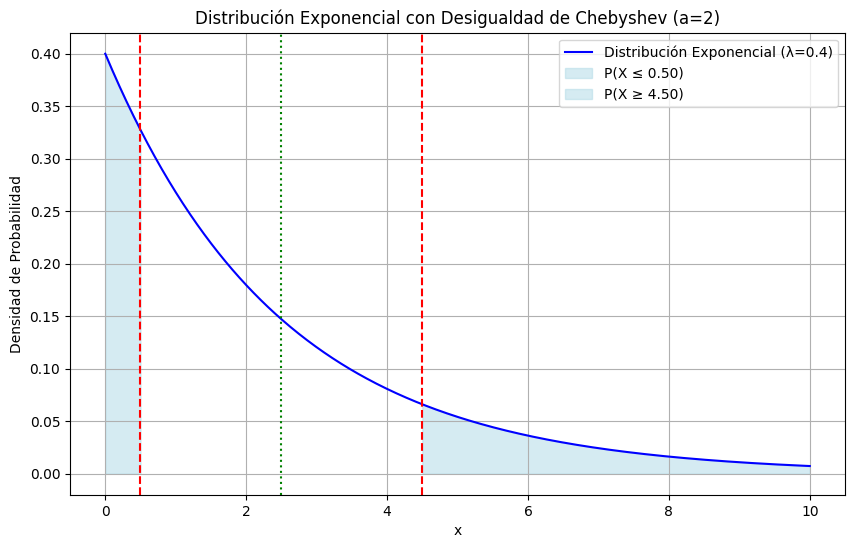

El área sombreada (P(|X-E[X]| ≥ 2)) es: 0.3466
El valor Var(X)/4 es: 1.5625
La desigualdad de Chebyshev (P(|X-E[X]| ≥ 2) ≤ Var(X)/4) se satisface: 0.3466 ≤ 1.5625


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon

lam = 0.4
x = np.linspace(0, 10, 500)
pdf = expon.pdf(x, scale=1/lam)             # Función de densidad de probabilidad
a = 2                                       # Valor para a
expected_value = (1/lam)                    # Calcula el valor esperado
variance = expon.var(scale=1/lam)           # Calcula la varianza

# Calculate the bounds for Chebyshev's inequality
lower_bound_chebyshev = expected_value - a
upper_bound_chebyshev = expected_value + a

# Calculate the probability P(|X-E[X]| >= a)
# Since X is non-negative, the lower tail starts from 0
prob_lower_tail = expon.cdf(max(0, lower_bound_chebyshev), scale=1/lam)
prob_upper_tail = expon.sf(upper_bound_chebyshev, scale=1/lam)
area_sombreada = prob_lower_tail + prob_upper_tail

plt.figure(figsize=(10, 6))
plt.plot(x, pdf, label=f'Distribución Exponencial (λ={lam})', color='blue')

x_fill_left = np.linspace(0, max(0, lower_bound_chebyshev), 100)   # Sombrea las regiones P(X <= E[X] - a) y P(X >= E[X] + a)
pdf_fill_left = expon.pdf(x_fill_left, scale=1/lam)
plt.fill_between(x_fill_left, pdf_fill_left, color='lightblue', alpha=0.5, label=f'P(X ≤ {max(0, lower_bound_chebyshev):.2f})')

x_fill_right = np.linspace(upper_bound_chebyshev, x.max(), 100)
pdf_fill_right = expon.pdf(x_fill_right, scale=1/lam)
plt.fill_between(x_fill_right, pdf_fill_right, color='lightblue', alpha=0.5, label=f'P(X ≥ {upper_bound_chebyshev:.2f})')

plt.title(f'Distribución Exponencial')
plt.xlabel('x')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid(True)
plt.axvline(expected_value, color='green', linestyle=':', label=f'E[X] = {expected_value:.2f}')
plt.axvline(max(0, lower_bound_chebyshev), color='red', linestyle='--', label=f'E[X] - a = {max(0, lower_bound_chebyshev):.2f}')
plt.axvline(upper_bound_chebyshev, color='red', linestyle='--', label=f'E[X] + a = {upper_bound_chebyshev:.2f}')
plt.show()

print(f"El área sombreada (P(|X-E[X]| ≥ {a})) es: {area_sombreada:.4f}")
print(f"El valor Var(X)/{a**2} es: {variance/a**2:.4f}")

if area_sombreada <= variance/a**2:
    print(f"La desigualdad de Chebyshev (P(|X-E[X]| ≥ {a}) ≤ Var(X)/{a**2}) se satisface: {area_sombreada:.4f} ≤ {variance/a**2:.4f}")
else:
    print(f"La desigualdad de Chebyshev (P(|X-E[X]| ≥ {a}) ≤ Var(X)/{a**2}) NO se satisface: {area_sombreada:.4f} > {variance/a**2:.4f}")

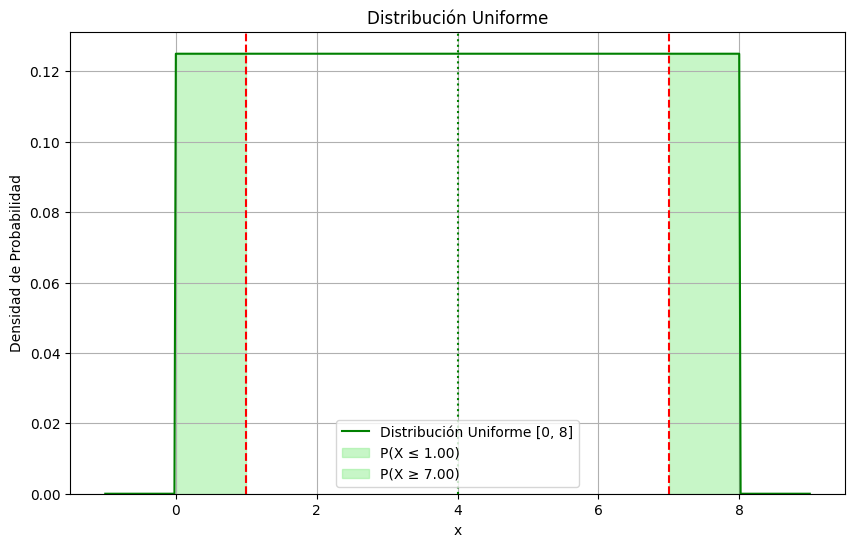

El área sombreada (P(|X-E[X]| ≥ 3)) es: 0.2500
El valor Var(X)/9 es: 0.5926
La desigualdad de Chebyshev (P(|X-E[X]| ≥ 3) ≤ Var(X)/9) se satisface: 0.2500 ≤ 0.5926


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform

uni_min = 0
uni_max = 8
uni_scale = uni_max - uni_min
x = np.linspace(uni_min - 1, uni_max + 1, 500)
pdf = uniform.pdf(x, loc=uni_min, scale=uni_scale)             # Función de densidad de probabilidad
a = 3                                                          # Valor para a
expected_value = (uni_min + uni_max) / 2                       # Calcula el valor esperado
variance_uniform = uniform.var(loc=uni_min, scale=uni_scale)   # Calcula la varianza

lower_bound_chebyshev = expected_value - a                     # Calcula los límites para la desigualdad
upper_bound_chebyshev = expected_value + a

prob_lower_tail = uniform.cdf(lower_bound_chebyshev, loc=uni_min, scale=uni_scale) # Calcula la probabilidad P(|X-E[X]| >= a)
prob_upper_tail = uniform.sf(upper_bound_chebyshev, loc=uni_min, scale=uni_scale)
area_sombreada = prob_lower_tail + prob_upper_tail

plt.figure(figsize=(10, 6))
plt.plot(x, pdf, label=f'Distribución Uniforme [{uni_min}, {uni_max}]', color='green')

x_fill_left = np.linspace(uni_min, min(uni_max, lower_bound_chebyshev), 100) # Sombrea las regiones P(X <= E[X] - a) y P(X >= E[X] + a)
pdf_fill_left = uniform.pdf(x_fill_left, loc=uni_min, scale=uni_scale)
plt.fill_between(x_fill_left, pdf_fill_left, color='lightgreen', alpha=0.5, label=f'P(X ≤ {min(uni_max, lower_bound_chebyshev):.2f})')

x_fill_right = np.linspace(max(uni_min, upper_bound_chebyshev), uni_max, 100)
pdf_fill_right = uniform.pdf(x_fill_right, loc=uni_min, scale=uni_scale)
plt.fill_between(x_fill_right, pdf_fill_right, color='lightgreen', alpha=0.5, label=f'P(X ≥ {max(uni_min, upper_bound_chebyshev):.2f})')

plt.title(f'Distribución Uniforme')
plt.xlabel('x')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid(True)
plt.axvline(expected_value, color='green', linestyle=':', label=f'E[X] = {expected_value:.2f}')
plt.axvline(lower_bound_chebyshev, color='red', linestyle='--', label=f'E[X] - a = {lower_bound_chebyshev:.2f}')
plt.axvline(upper_bound_chebyshev, color='red', linestyle='--', label=f'E[X] + a = {upper_bound_chebyshev:.2f}')
plt.ylim(bottom=0)
plt.show()

print(f"El área sombreada (P(|X-E[X]| ≥ {a})) es: {area_sombreada:.4f}")
print(f"El valor Var(X)/{a**2} es: {variance_uniform/a**2:.4f}")

if area_sombreada <= variance_uniform/a**2:
    print(f"La desigualdad de Chebyshev (P(|X-E[X]| ≥ {a}) ≤ Var(X)/{a**2}) se satisface: {area_sombreada:.4f} ≤ {variance_uniform/a**2:.4f}")
else:
    print(f"La desigualdad de Chebyshev (P(|X-E[X]| ≥ {a}) ≤ Var(X)/{a**2}) NO se satisface: {area_sombreada:.4f} > {variance_uniform/a**2:.4f}")